# Regressão Não Linear e Transformação de Box-Cox

## 1. Regressão Não Linear
A Regressão Não Linear é usada quando a relação entre a causa ($X$) e o resultado ($Y$) **não segue uma linha reta constante**. 

* **O Problema da Linha Reta:** Na regressão linear, assumimos que se $X$ sobe 1 passo, $Y$ sobe sempre a mesma quantidade. Mas no mundo real, muitas coisas fazem curvas (aceleram, desaceleram ou chegam a um limite).
* **A Solução:** A regressão não linear desenha uma **curva** (que pode ser em formato de U, um arco, uma onda, etc.) para se ajustar perfeitamente aos dados. 
* **Exemplo Prático:** O crescimento de uma bactéria ou o rendimento de juros compostos. No começo cresce devagar, mas depois "explode" para cima. Uma linha reta erraria feio ao tentar prever isso; uma curva acerta em cheio.

---

## 2. Transformação de Box-Cox
A Transformação de Box-Cox é um "truque" matemático (ou um atalho inteligente) para consertar dados tortos. 

Modelos de Regressão Linear tradicionais adoram dados com comportamento "normal" (a famosa curva em formato de sino) e relações lineares. Quando seus dados são curvos ou assimétricos, você tem duas opções: criar um modelo não-linear complexo (como vimos acima) **OU** usar o Box-Cox.

* **O que ele faz:** Ele pega a sua variável dependente ($Y$) e testa automaticamente várias transformações matemáticas nela (como aplicar o logaritmo, raiz quadrada, inverso, etc.).
* **O parâmetro Lambda ($\lambda$):** O Box-Cox usa um valor chamado Lambda para descobrir qual dessas transformações deixa os seus dados o mais "normais" e lineares possível.
* **O Objetivo:** Ele "estica e amassa" os dados curvos até que eles fiquem em um formato que uma Regressão Linear simples consiga entender e processar sem gerar aqueles erros bizarros (resíduos altos).

---

## Em Resumo
* A **Regressão Não Linear** é você mudar a **ferramenta** (usar uma equação curva) para se adaptar aos dados complexos.
* A **Transformação de Box-Cox** é você mudar os **dados** (transformá-los) para poder continuar usando a sua ferramenta simples(a regressão linear).

In [39]:
import pandas as pd # manipulação de dados em formato de dataframe
import numpy as np # operações matemáticas
import seaborn as sns # visualização gráfica
import matplotlib.pyplot as plt # visualização gráfica
import plotly.graph_objects as go # gráficos 3D
from scipy.stats import pearsonr # correlações de Pearson
import statsmodels.api as sm # estimação de modelos
from statsmodels.iolib.summary2 import summary_col # comparação entre modelos
from sklearn.preprocessing import LabelEncoder # transformação de dados
import pingouin as pg # outro modo para obtenção de matrizes de correlações
from statstests.process import stepwise # procedimento Stepwise
from statstests.tests import shapiro_francia # teste de Shapiro-Francia
from scipy.stats import boxcox # transformação de Box-Cox
from scipy.stats import norm # para plotagem da curva normal
from scipy import stats # utilizado na definição da função 'breusch_pagan_test'


import warnings
warnings.filterwarnings('ignore')

#### CARREGAMENTO DA BASE DE DADOS

In [40]:
df_bebes = pd.read_csv('bebes.csv', delimiter=',')
df_bebes

,comprimento,idade
0,63.07,19.00
1,65.63,21.00
2,65.63,22.50
3,66.73,22.50
4,66.37,23.25
...,...,...
69,75.90,30.50
70,78.47,31.00
71,80.67,36.50
72,81.03,38.00


In [41]:
# Características das variáveis do dataset
df_bebes.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   comprimento  74 non-null     float64
 1   idade        74 non-null     float64
dtypes: float64(2)
memory usage: 1.3 KB


In [42]:
# Estatísticas univariadas
df_bebes.describe()

,comprimento,idade
count,74.000000,74.000000
mean,66.921622,25.312162
std,12.852386,12.975168
min,31.900000,2.150000
25%,56.470000,12.500000
50%,70.400000,26.000000
75%,75.807500,33.000000
max,87.630000,60.000000


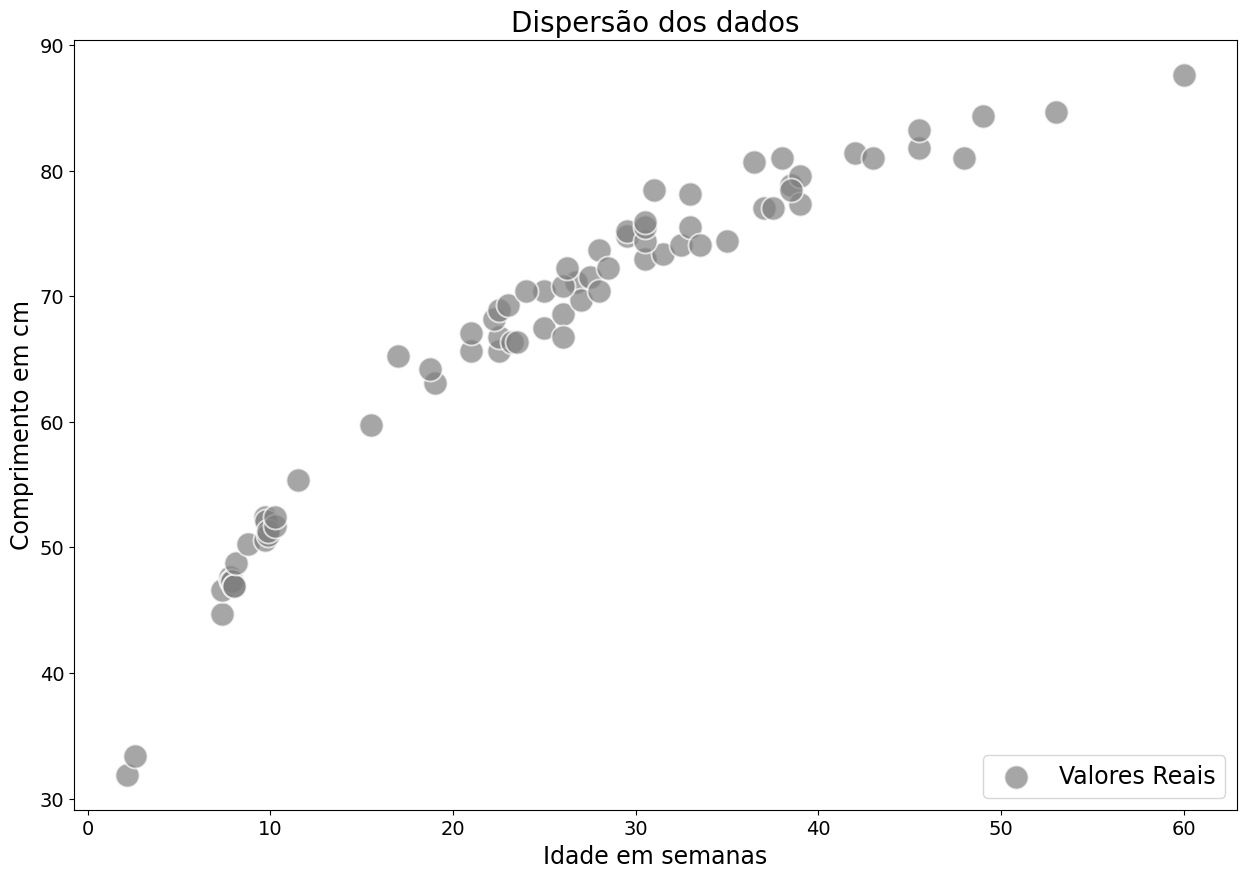

In [43]:
# Gráfico de dispersão

plt.figure(figsize=(15,10))
sns.scatterplot(x="idade", y="comprimento", data=df_bebes, color='grey',
                s=300, label='Valores Reais', alpha=0.7)
plt.title('Dispersão dos dados', fontsize=20)
plt.xlabel('Idade em semanas', fontsize=17)
plt.ylabel('Comprimento em cm', fontsize=17)
plt.legend(loc='lower right', fontsize=17)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

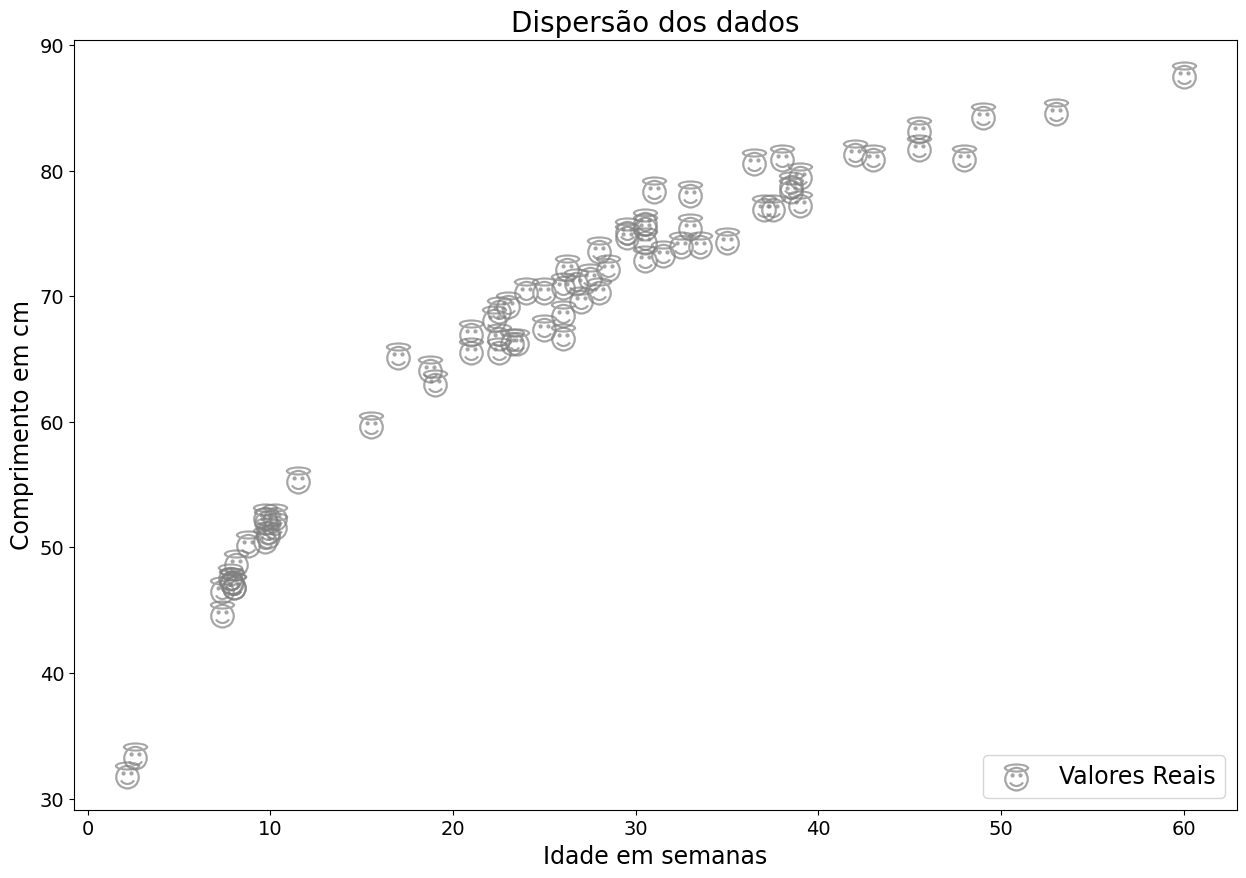

In [44]:
# In[4.2]: Gráfico de dispersão com emojis 01

plt.figure(figsize=(15, 10))
plt.scatter(x="idade", y="comprimento", data=df_bebes, color='grey',
            s=400, label='Valores Reais', alpha=0.7, marker='$\U0001F607$',
            linewidth=0.2)
plt.title('Dispersão dos dados', fontsize=20)
plt.xlabel('Idade em semanas', fontsize=17)
plt.ylabel('Comprimento em cm', fontsize=17)
plt.legend(loc='lower right', fontsize=17)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()


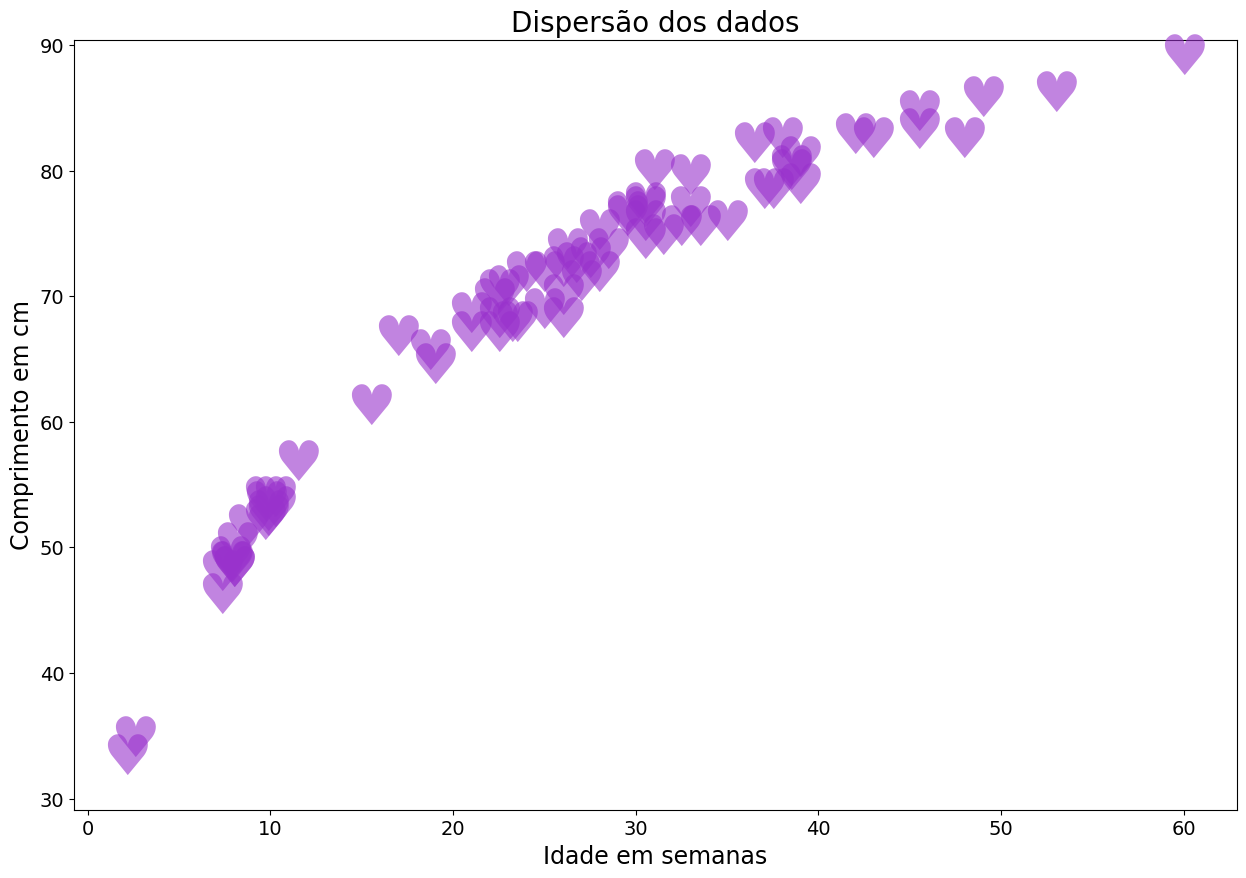

In [45]:
#Gráfico de dispersão com emojis 02

emojis_coracao = ['♥'] * len(df_bebes)

plt.figure(figsize=(15, 10))
sns.scatterplot(x="idade", y="comprimento", data=df_bebes, color='none',
                s=0, label=None)
for i, emoji in enumerate(emojis_coracao):
    plt.text(df_bebes['idade'][i], df_bebes['comprimento'][i], emoji,
             fontsize=40, ha='center', alpha=0.6, color='darkorchid')
plt.title('Dispersão dos dados', fontsize=20)
plt.xlabel('Idade em semanas', fontsize=17)
plt.ylabel('Comprimento em cm', fontsize=17)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

# Estimação de um modelo OLS linear

In [46]:
# ---------------------------------------------------------
# PARTE 1: A MATEMÁTICA (Calculando o Modelo Linear)
# ---------------------------------------------------------

# Aqui o computador calcula a equação da Reta (Regressão Linear Simples).
# Ele tenta prever o 'comprimento' do bebê baseado na 'idade'.
# O '.fit()' é a ordem para executar os cálculos matemáticos.
modelo_linear = sm.OLS.from_formula('comprimento ~ idade', df_bebes).fit()

# Aqui ele imprime aquele "boletim de notas" do modelo que analisamos antes
# (vai mostrar o R-quadrado, P-valor e os coeficientes da reta).
print(modelo_linear.summary())

                            OLS Regression Results                            
Dep. Variable:            comprimento   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     667.7
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           3.72e-38
Time:                        19:53:51   Log-Likelihood:                -207.26
No. Observations:                  74   AIC:                             418.5
Df Residuals:                      72   BIC:                             423.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     43.1004      1.034     41.665      0.0

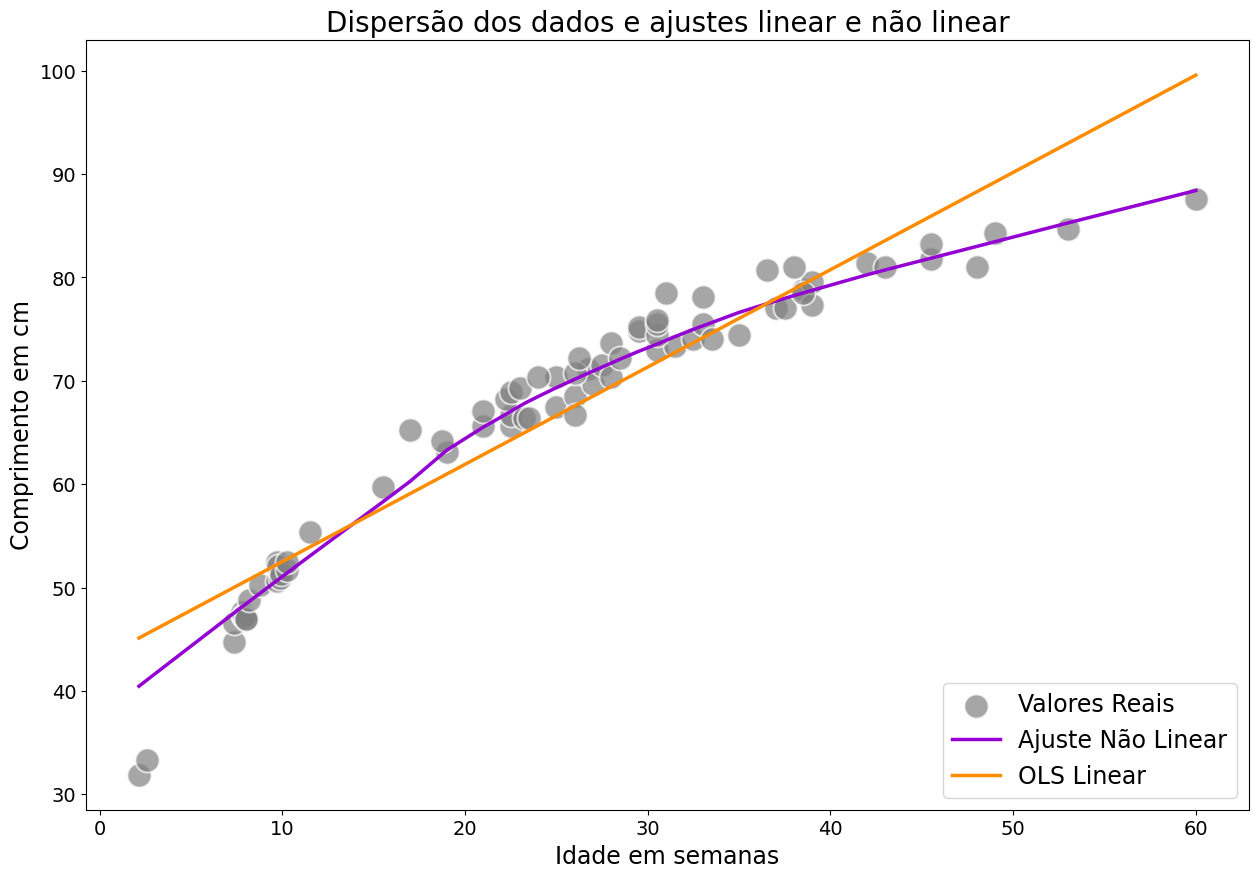

In [47]:
# ---------------------------------------------------------
# PARTE 2: A VISUALIZAÇÃO (Desenhando o Gráfico)
# ---------------------------------------------------------

# Cria uma "tela em branco" para o gráfico com tamanho 15 (largura) por 10 (altura).
plt.figure(figsize=(15,10))

# 1. PLOTANDO OS DADOS REAIS (Os pontinhos)
# sns.scatterplot pega os dados da tabela e desenha os pontos cinzas.
# 's=300' é o tamanho da bolinha e 'alpha=0.7' deixa ela um pouco transparente.
sns.scatterplot(x="idade", y="comprimento", data=df_bebes, color='grey',
                s=300, label='Valores Reais', alpha=0.7)

# 2. PLOTANDO O AJUSTE NÃO LINEAR (A Curva - Dark Violet)
# sns.regplot desenha uma linha de tendência.
# O SEGREDO ESTÁ AQUI: 'lowess=True' obriga a linha a ser flexível (Não Linear).
# Ele olha para pedaços pequenos dos dados e vai desenhando uma curva suave.
# 'scatter=False' diz para não desenhar as bolinhas de novo (já fizemos em cima).
# 'ci=False' remove aquela sombra de margem de erro ao redor da linha.
sns.regplot(x="idade", y="comprimento", data=df_bebes, lowess=True,
            color='darkviolet', ci=False, scatter=False,
            label='Ajuste Não Linear',
            line_kws={'linewidth': 2.5}) # Deixa a linha mais grossa (2.5)

# 3. PLOTANDO O AJUSTE LINEAR (A Reta - Dark Orange)
# Aqui usamos o sns.regplot de novo, mas SEM o 'lowess=True'.
# Por padrão, ele desenha uma linha reta "dura" (o modelo OLS tradicional).
sns.regplot(x="idade", y="comprimento", data=df_bebes,
            color='darkorange', ci=False, scatter=False,
            label='OLS Linear',
            line_kws={'linewidth': 2.5})

# ---------------------------------------------------------
# PARTE 3: A "MAQUIAGEM" DO GRÁFICO (Títulos e Textos)
# ---------------------------------------------------------

# Coloca o título principal lá no topo do gráfico.
plt.title('Dispersão dos dados e ajustes linear e não linear', fontsize=20)

# Nomeia o eixo X (horizontal) e o eixo Y (vertical).
plt.xlabel('Idade em semanas', fontsize=17)
plt.ylabel('Comprimento em cm', fontsize=17)

# Posiciona a legenda explicativa no canto inferior direito ('lower right').
plt.legend(loc='lower right', fontsize=17)

# Aumenta o tamanho dos numerozinhos que ficam nos eixos X e Y.
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Mostra a imagem final montada na tela!
plt.show()

# Análise de Ajuste: Linear vs Não Linear (Crescimento de Bebês)

## 1. O Comportamento dos Dados Reais (Pontos Cinzas)
Olhando apenas para as bolinhas cinzas, fica claro que o crescimento do bebê não é constante.
* Nas primeiras semanas (0 a 20), a inclinação é muito íngreme; o bebê cresce muito rápido.
* Conforme o tempo passa (após as 40 semanas), o crescimento começa a desacelerar e a curva vai ficando mais deitada.

## 2. O Fracasso do Modelo Linear (Linha Laranja - OLS)
A linha reta (laranja) representa a tentativa de aplicar a regra matemática rígida: "para cada semana a mais, o bebê cresce sempre X centímetros". Veja como isso gera o clássico **Underfitting** (subajuste):
* **Início (0 a 10 semanas):** A reta superestima o tamanho. Ela diz que o bebê deveria ser maior do que realmente é (a linha passa acima dos pontos).
* **Meio (15 a 40 semanas):** A reta subestima o tamanho. Como a reta é engessada, ela acaba passando muito abaixo da nuvem de pontos reais.
* **Fim (45 a 60 semanas):** O pior erro. O crescimento real do bebê estabiliza (chegando a uns 88 cm), mas a reta ignorou isso e continuou subindo infinitamente, prevendo quase 100 cm. Se você usasse a linha laranja para prever o comprimento de uma criança maior, o modelo entregaria um resultado absurdo.

## 3. O Sucesso do Ajuste Não Linear (Curva Roxa - LOWESS)
A curva roxa (que o seu código gerou ativando `lowess=True`) é flexível. Em vez de impor uma regra única do começo ao fim, ela "escuta" os dados locais.
* Ela acompanha com precisão o "estirão" das primeiras semanas.
* Ela faz a curva exata no momento em que o crescimento começa a desacelerar.
* A distância (os resíduos) entre os pontos cinzas e a curva roxa é minúscula o tempo todo.

---

## Qual é o veredito prático?
Se você precisa construir um sistema para prever o tamanho de recém-nascidos em um hospital, este gráfico **proíbe o uso de uma Regressão Linear Simples** com os dados originais.

Para resolver matematicamente o que a linha roxa desenhou visualmente, você teria que aplicar aquilo que estudamos no bloco anterior: ou criar um modelo polinomial (ex: $Y = \\beta_0 + \\beta_1 X + \\beta_2 X^2$) ou usar técnicas como a **Transformação de Box-Cox** (ou simplesmente aplicar Logaritmo na idade) para "esticar" essa curva roxa até ela virar uma reta que o modelo OLS consiga ler sem cometer aqueles erros crassos nos extremos!

# Teste de verificação da aderência dos resíduos à normalidade

In [48]:
# In[4.6]: Teste de verificação da aderência dos resíduos à normalidade

# Teste de Shapiro-Wilk (n < 30)
# from scipy.stats import shapiro
# shapiro(modelo_linear.resid)

# Teste de Shapiro-Francia (n >= 30)
# Carregamento da função 'shapiro_francia' do pacote 'statstests.tests'
# Autores do pacote: Luiz Paulo Fávero e Helder Prado Santos
# https://stats-tests.github.io/statstests/

# from statstests.tests import shapiro_francia

# Teste de Shapiro-Francia: interpretação
teste_sf = shapiro_francia(modelo_linear.resid) #criação do objeto 'teste_sf'
teste_sf = teste_sf.items() #retorna o grupo de pares de valores-chave no dicionário
method, statistics_W, statistics_z, p = teste_sf #definição dos elementos da lista (tupla)
print('Statistics W=%.5f, p-value=%.6f' % (statistics_W[1], p[1]))
alpha = 0.05 #nível de significância
if p[1] > alpha:
	print('Não se rejeita H0 - Distribuição aderente à normalidade')
else:
	print('Rejeita-se H0 - Distribuição não aderente à normalidade')


method  :  Shapiro-Francia normality test
statistics W  :  0.9087044262594459
statistics z  :  3.6276504915453778
p-value  :  0.0001430060355543775
Statistics W=0.90870, p-value=0.000143
Rejeita-se H0 - Distribuição não aderente à normalidade


## 1. O que é esse teste?
O teste de Shapiro-Francia é uma ferramenta estatística usada para verificar se um conjunto de dados segue uma **distribuição normal** (a famosa curva em formato de sino). Na regressão linear, existe uma regra fundamental: os **resíduos** (os erros de previsão do modelo) precisam seguir essa distribuição normal para que o modelo seja considerado estatisticamente válido.

## 2. Entendendo as Hipóteses
Todo teste de normalidade trabalha com um duelo entre duas hipóteses:
* **$H_0$ (Hipótese Nula):** Os resíduos têm uma distribuição normal. (É o que você *quer* que aconteça no modelo linear).
* **$H_1$ (Hipótese Alternativa):** Os resíduos **NÃO** têm uma distribuição normal. (É o sinal de alerta).

## 3. O que o seu código fez?
1. Ele extraiu apenas os resíduos (erros) do seu modelo (`modelo_linear.resid`).
2. Rodou o cálculo estatístico e devolveu duas métricas principais: a Estatística $W$ ($0.9087$) e, mais importante, o **P-valor** ($0.000143$).
3. Fez a pergunta lógica: *O P-valor é maior ou menor que o meu $\\alpha$ de $0.05$ (5%)?*

## 4. A Conclusão (O Veredito do Teste)
O resultado cravou: **Rejeita-se $H_0$ - Distribuição não aderente à normalidade**.

Como o seu P-valor ($0.000143$) é extremamente menor que $0.05$, a estatística prova que os erros do seu modelo não são aleatórios e normais. 

**O que isso significa na prática?**
Lembra do gráfico anterior onde a linha reta laranja errava muito no começo e no fim, mas cruzava os pontos no meio? O teste de Shapiro-Francia acabou de provar **matematicamente** o que você viu **visualmente**. 

Como você tentou forçar uma linha reta em um problema que claramente é uma curva (crescimento de bebês), o modelo errou seguindo um padrão previsível. Esses erros padronizados destruíram a regra da "normalidade". O teste está te dizendo oficialmente: *"O modelo linear falhou. Você precisa transformar esses dados (ex: Box-Cox) ou usar uma regressão não-linear."*

# Transformação de Box-Cox

In [49]:
# Transformação de Box-Cox

# Para o cálculo do lambda de Box-Cox
# from scipy.stats import boxcox

# 'yast' é uma variável que traz os valores transformados (Y*)
# 'lmbda' é o lambda de Box-Cox
yast, lmbda = boxcox(df_bebes['comprimento'])

# Inserção da variável transformada ('bc_comprimento') no dataset para a
#estimação de um novo modelo
df_bebes['bc_comprimento'] = yast

df_bebes



,comprimento,idade,bc_comprimento
0,63.07,19.00,22966.092606
1,65.63,21.00,25529.075884
2,65.63,22.50,25529.075884
3,66.73,22.50,26682.733457
4,66.37,23.25,26301.668594
...,...,...,...
69,75.90,30.50,37577.506812
70,78.47,31.00,41056.620650
71,80.67,36.50,44189.027404
72,81.03,38.00,44715.337339


## 1. O que é e o que faz?
A Transformação de Box-Cox é uma **ferramenta de preparação de dados**. Ela pega nos números originais de uma variável (como o comprimento dos bebés) e aplica uma fórmula matemática para "esticar" ou "encolher" esses números.

## 2. Qual o objetivo e porquê usar?
O objetivo principal é **consertar dados que não são lineares ou que não têm uma distribuição normal** (como foi provado pelo seu teste de Shapiro-Francia).

Modelos de Regressão Linear (OLS) são "chatos": eles exigem que a relação entre os dados seja uma linha reta e que os erros sejam normais. Se os seus dados fazem uma curva, o modelo OLS falha. Usamos o Box-Cox para "desamassar" essa curva, forçando os dados a ficarem alinhados para que a Regressão Linear simples consiga funcionar perfeitamente.

## 3. Isso já é o modelo final?
**NÃO.** A Transformação de Box-Cox não é um modelo preditivo. Ela não faz previsões.

O Box-Cox apenas cria uma **nova variável** (a nova coluna `bc_comprimento` que gerou no código).

## 4. Onde ela entra então?
Ela entra no passo imediatamente anterior à criação do modelo final. A sequência exata é esta:

1. Tentou fazer o modelo com os dados originais e viu que falhou (a linha laranja não acompanhou a curva).
2. Usou o Box-Cox para criar uma nova variável corrigida.
3. **O Próximo Passo:** Agora, vai criar um **NOVO modelo OLS**, mas em vez de pedir para ele prever o comprimento original, vai pedir para ele prever a nova variável `bc_comprimento`.

> **Em resumo:** O Box-Cox não é o destino final, é apenas a "maquilhagem" que aplica nos dados para que o modelo final os consiga ler corretamente.

# Entendendo o Código da Transformação de Box-Cox

Esse trecho de código é o momento prático onde a teoria do Box-Cox é aplicada aos seus dados. Ele pega aquela variável que estava causando problemas (reprovando no teste de normalidade) e a transforma para salvar o seu modelo linear.

Vamos quebrar o código linha a linha:

## 1. A Mágica Matemática
`yast, lmbda = boxcox(df_bebes['comprimento'])`

* **`boxcox(...)`**: É a função (geralmente da biblioteca `scipy.stats`) que faz todo o trabalho pesado. Você entrega para ela a coluna original que está com o comportamento não-linear (neste caso, o `comprimento` dos bebês).
* **O que a função devolve?** Ela faz os cálculos e devolve dois resultados ao mesmo tempo, que você guarda em duas variáveis separadas:
    * **`yast`** (Y-asterisco ou $Y^*$): É a lista completa com os **novos valores transformados**. São os comprimentos originais depois de passarem pelo ajuste matemático.
    * **`lmbda`** (Lambda ou $\\lambda$): É o "número mágico" que o algoritmo encontrou. O computador testou várias transformações internamente e descobriu que aplicar *este* valor específico de $\\lambda$ é o que deixa os seus dados o mais aderentes possível a uma distribuição normal.

## 2. Guardando o Resultado
`df_bebes['bc_comprimento'] = yast`

* Agora que você tem os novos valores transformados (`yast`), você precisa salvá-los na sua base de dados.
* Este comando simplesmente **cria uma nova coluna** na sua tabela (DataFrame) chamada `bc_comprimento` (o "bc" indica que passou pelo Box-Cox) e insere todos os novos valores nela.

## 3. Visualizando a Tabela
`df_bebes`

* Ao digitar apenas o nome do DataFrame no final da célula, o Python exibe a tabela atualizada na tela.
* Ao olhar os dados, você verá a nova coluna. Se um bebê tinha `comprimento` real de 50cm, a nova coluna `bc_comprimento` terá um número completamente diferente, transformado matematicamente, mas que agora "engana" o modelo e permite o ajuste de uma linha reta perfeita.

---

### O Veredito Prático (Próximos Passos)
Com essa nova coluna criada, você deve abandonar a variável antiga (`comprimento`) e treinar um **novo modelo OLS** usando a variável `bc_comprimento` como o seu novo $Y$. Se você rodar aquele teste de *Shapiro-Francia* nos resíduos desse novo modelo, ele muito provavelmente será aprovado, validando estatisticamente a sua regressão!
"""

file_path = "explicacao_codigo_boxcox.md"
with open(file_path, "w", encoding="utf-8") as f:
    f.write(markdown_content)

print(f"File successfully created at {file_path}")

In [50]:
# Verificação do cálculo, apenas para fins didáticos
df_bebes['bc_comprimento2'] = ((df_bebes['comprimento']**lmbda)-1)/lmbda

df_bebes

,comprimento,idade,bc_comprimento,bc_comprimento2
0,63.07,19.00,22966.092606,22966.092606
1,65.63,21.00,25529.075884,25529.075884
2,65.63,22.50,25529.075884,25529.075884
3,66.73,22.50,26682.733457,26682.733457
4,66.37,23.25,26301.668594,26301.668594
...,...,...,...,...
69,75.90,30.50,37577.506812,37577.506812
70,78.47,31.00,41056.620650,41056.620650
71,80.67,36.50,44189.027404,44189.027404
72,81.03,38.00,44715.337339,44715.337339


In [51]:
del df_bebes['bc_comprimento2']

df_bebes

,comprimento,idade,bc_comprimento
0,63.07,19.00,22966.092606
1,65.63,21.00,25529.075884
2,65.63,22.50,25529.075884
3,66.73,22.50,26682.733457
4,66.37,23.25,26301.668594
...,...,...,...
69,75.90,30.50,37577.506812
70,78.47,31.00,41056.620650
71,80.67,36.50,44189.027404
72,81.03,38.00,44715.337339


# Estimando um novo modelo OLS com variável dependente

In [52]:
# In[4.9]: Estimando um novo modelo OLS com variável dependente
#transformada por Box-Cox

modelo_bc = sm.OLS.from_formula('bc_comprimento ~ idade', df_bebes).fit()

# Parâmetros do 'modelo_bc'
print(modelo_bc.summary())


                            OLS Regression Results                            
Dep. Variable:         bc_comprimento   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     1822.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           7.16e-53
Time:                        19:53:55   Log-Likelihood:                -681.77
No. Observations:                  74   AIC:                             1368.
Df Residuals:                      72   BIC:                             1372.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4995.1615    630.253      7.926      0.0

# Análise do Novo Modelo OLS (Após Box-Cox)

Este é o "boletim de notas" do seu novo modelo, e os resultados mostram que a Transformação de Box-Cox foi um sucesso absoluto! Vamos analisar as três partes mais importantes:

## 1. O Desempenho do Modelo (R-Quadrado)
Olhe para o **`R-squared: 0.962`** no topo direito.
* **O que significa:** Neste novo formato transformado, a `idade` consegue explicar impressionantes **96,2%** do comportamento do comprimento ajustado (`bc_comprimento`).
* **Comparação:** É um ajuste quase perfeito. A linha reta agora passa exatamente no meio da nuvem de pontos (que foi "esticada" pelo Box-Cox).

## 2. A Nova Equação (Os Coeficientes)
A tabela do meio nos dá a nova matemática do modelo:
* **Intercept:** 4995.16
* **idade:** 947.23 (P-valor = 0.000, ou seja, totalmente significante).
* **Atenção:** Estes números gigantes **NÃO estão em centímetros**! Como você aplicou o Box-Cox, a unidade de medida mudou. Você não pode mais dizer que "o bebê cresce 947 cm por semana". Para voltar a ter resultados em centímetros, você terá que fazer a operação matemática inversa do Box-Cox no final.

## 3. A Prova do Sucesso (Adeus, Erro de Normalidade!)
Lembra que o modelo anterior reprovou no teste de Shapiro-Francia porque os erros não formavam uma curva normal? Olhe para o final deste relatório:

* **Prob(Omnibus): 0.566**
* **Prob(JB): 0.757**

O Omnibus e o Jarque-Bera (JB) também são testes de normalidade (funcionam com a mesma lógica do Shapiro-Francia). 
* **A regra de ouro:** Se o Prob for **MAIOR que 0.05**, os resíduos são normais (Não rejeitamos a Hipótese Nula $H_0$).
* Como tiramos notas altas (0.56 e 0.75), **o seu modelo acaba de ser aprovado!** Os erros agora são aleatórios e bem distribuídos (Skew muito perto de 0 e Kurtosis perto de 3).

---

## O Veredito Prático
Você pegou um modelo que estava matematicamente quebrado (underfitting e erros não-normais), aplicou um "remédio" nos dados (Box-Cox) e agora tem um modelo de regressão linear que é **robusto, confiável e estatisticamente válido**. Missão cumprida!

In [53]:
# In[4.10]: Comparando os parâmetros do 'modelo_linear' com os do 'modelo_bc'

# CUIDADO!!! OS PARÂMETROS NÃO SÃO DIRETAMENTE COMPARÁVEIS!

summary_col([modelo_linear, modelo_bc])

# Outro modo mais completo também pela função 'summary_col'
summary_col([modelo_linear, modelo_bc],
            model_names=["MODELO LINEAR","MODELO BOX-COX"],
            stars=True,
            info_dict = {
                'N':lambda x: "{0:d}".format(int(x.nobs))
        })

# Repare que há um salto na qualidade do ajuste para o modelo não linear (R²)

pd.DataFrame({'R² OLS':[round(modelo_linear.rsquared,4)],
              'R² Box-Cox':[round(modelo_bc.rsquared,4)]})

,R² OLS,R² Box-Cox
0,0.9027,0.962


In [54]:
# In[4.11]: Verificando a normalidade dos resíduos do 'modelo_bc'

# Teste de Shapiro-Francia: interpretação
teste_sf = shapiro_francia(modelo_bc.resid) #criação do objeto 'teste_sf'
teste_sf = teste_sf.items() #retorna o grupo de pares de valores-chave no dicionário
method, statistics_W, statistics_z, p = teste_sf #definição dos elementos da lista (tupla)
print('Statistics W=%.5f, p-value=%.6f' % (statistics_W[1], p[1]))
alpha = 0.05 #nível de significância
if p[1] > alpha:
	print('Não se rejeita H0 - Distribuição aderente à normalidade')
else:
	print('Rejeita-se H0 - Distribuição não aderente à normalidade')

method  :  Shapiro-Francia normality test
statistics W  :  0.9729952064687974
statistics z  :  1.266615452389088
p-value  :  0.10264641223384241
Statistics W=0.97300, p-value=0.102646
Não se rejeita H0 - Distribuição aderente à normalidade


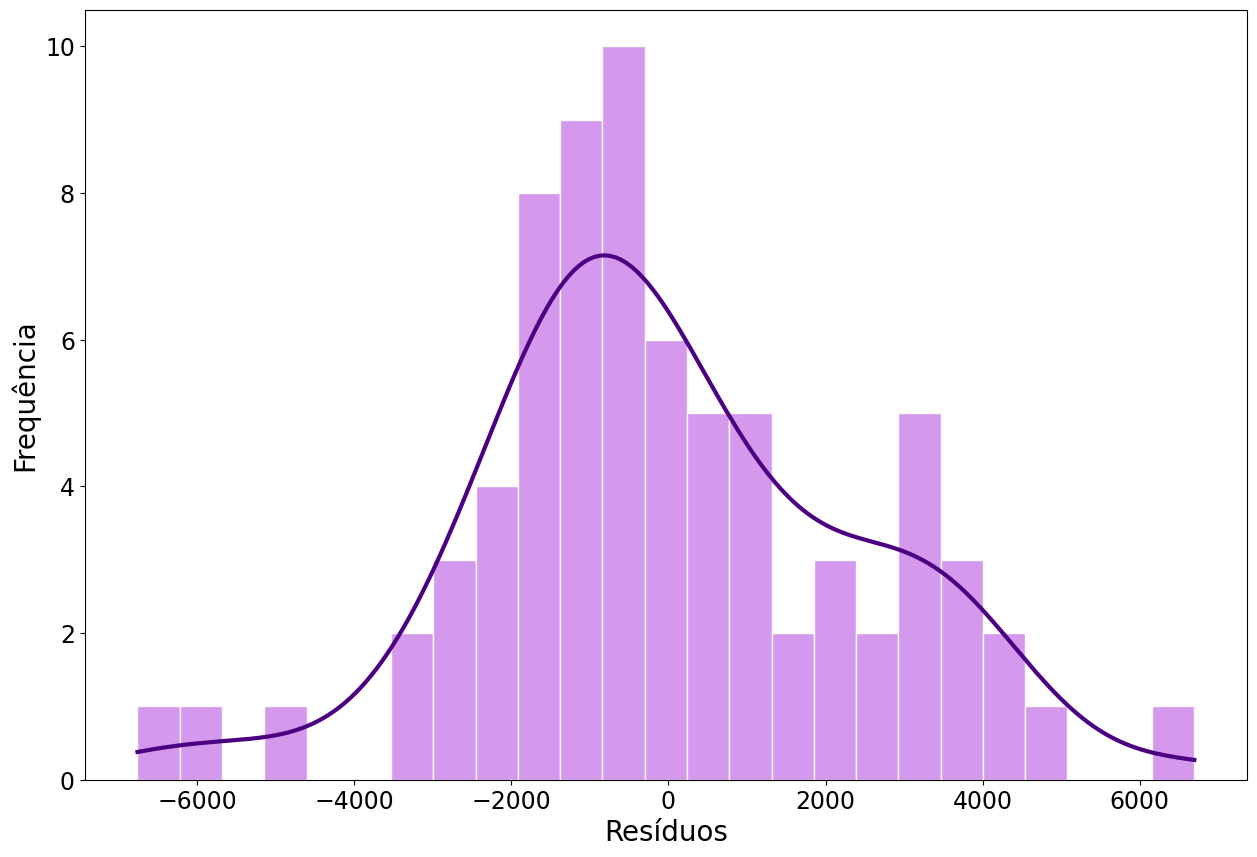

In [55]:
# In[4.12]: Histograma dos resíduos do modelo_bc

plt.figure(figsize=(15,10))
hist2 = sns.histplot(data=modelo_bc.resid, kde=True, bins=25,
                     color='darkviolet', alpha=0.4, edgecolor='snow',
                     line_kws={'linewidth': 3})
hist2.get_lines()[0].set_color('indigo')
plt.xlabel('Resíduos', fontsize=20)
plt.ylabel('Frequência', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.show()

# Fazendo predições com os modelos OLS linear e Box-Cox

In [56]:
# In[4.13]: Fazendo predições com os modelos OLS linear e Box-Cox
# Qual é o comprimento esperado de um bebê com 52 semanas de vida?

# Modelo OLS Linear:
modelo_linear.predict(pd.DataFrame({'idade':[52]}))



0    92.037486
dtype: float64

In [57]:
# Modelo Não Linear (Box-Cox):
modelo_bc.predict(pd.DataFrame({'idade':[52]}))

0    54251.133574
dtype: float64

# -->

In [58]:
# Não podemos nos esquecer de fazer o cálculo inverso para a obtenção do fitted
#value de Y (variável 'comprimento')
float((54251.133574 * lmbda + 1) ** (1 / lmbda))

87.14006452641158

In [59]:
# Salvando os fitted values dos dois modelos (modelo_linear
#e modelo_bc) no dataset 'bebes'

df_bebes['yhat_linear'] = modelo_linear.fittedvalues
df_bebes['yhat_modelo_bc'] = (modelo_bc.fittedvalues * lmbda + 1) ** (1 / lmbda)
df_bebes


,comprimento,idade,bc_comprimento,yhat_linear,yhat_modelo_bc
0,63.07,19.00,22966.092606,60.981260,63.097300
1,65.63,21.00,25529.075884,62.863455,65.004303
2,65.63,22.50,25529.075884,64.275102,66.375858
3,66.73,22.50,26682.733457,64.275102,66.375858
4,66.37,23.25,26301.668594,64.980925,67.044337
...,...,...,...,...,...
69,75.90,30.50,37577.506812,71.803884,73.004869
70,78.47,31.00,41056.620650,72.274433,73.386942
71,80.67,36.50,44189.027404,77.450471,77.388462
72,81.03,38.00,44715.337339,78.862117,78.422026


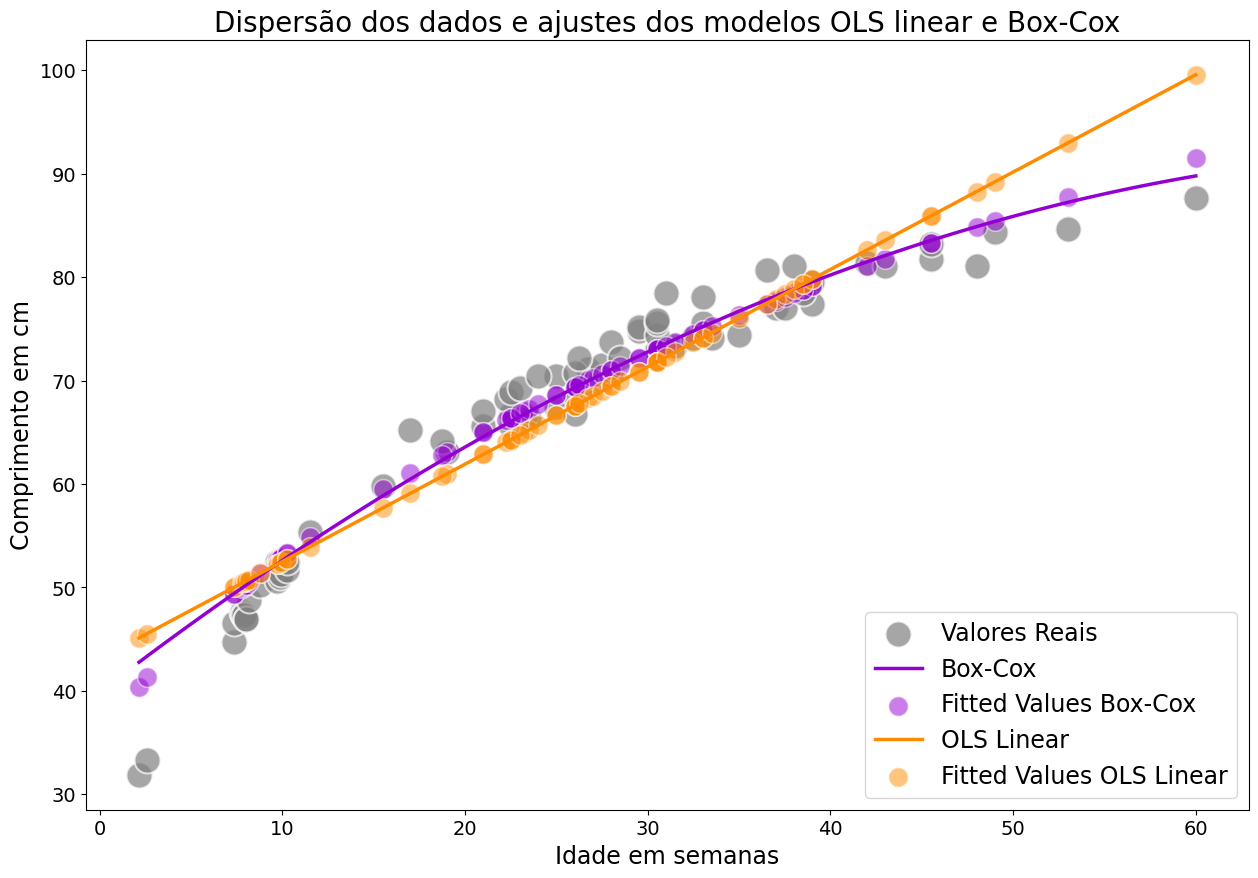

In [60]:
# Gráfico de dispersão com ajustes dos modelos OLS linear e Box-Cox

plt.figure(figsize=(15,10))
sns.scatterplot(x="idade", y="comprimento", data=df_bebes, color='grey',
                s=350, label='Valores Reais', alpha=0.7)
sns.regplot(x="idade", y="yhat_modelo_bc", data=df_bebes, order=lmbda,
            color='darkviolet', ci=False, scatter=False, label='Box-Cox',
            line_kws={'linewidth': 2.5})
sns.scatterplot(x="idade", y="yhat_modelo_bc", data=df_bebes, color='darkviolet',
                s=200, label='Fitted Values Box-Cox', alpha=0.5)
sns.regplot(x="idade", y="yhat_linear", data=df_bebes,
            color='darkorange', ci=False, scatter=False, label='OLS Linear',
            line_kws={'linewidth': 2.5})
sns.scatterplot(x="idade", y="yhat_linear", data=df_bebes, color='darkorange',
                s=200, label='Fitted Values OLS Linear', alpha=0.5)
plt.title('Dispersão dos dados e ajustes dos modelos OLS linear e Box-Cox',
          fontsize=20)
plt.xlabel('Idade em semanas', fontsize=17)
plt.ylabel('Comprimento em cm', fontsize=17)
plt.legend(loc='lower right', fontsize=17)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [61]:
# In[4.16]: Gráfico de dispersão com ajustes dos modelos OLS linear e Box-Cox,
#com interação (figura 'EXEMPLO4.html' salva na pasta do curso)

# Ajuste polinomial com grau igual a lambda (lmbda = 2.659051008426254)
coefficients = np.polyfit(df_bebes["idade"], df_bebes["yhat_modelo_bc"], lmbda)
x_range = np.linspace(df_bebes["idade"].min(), df_bebes["idade"].max(), 100)
y_quadratic = np.polyval(coefficients, x_range)

fig = go.Figure()

fig.add_trace(go.Scatter(x=df_bebes["idade"], y=df_bebes["comprimento"],
                         mode='markers',
                         marker=dict(color='grey', opacity=0.7, size=20),
                         name='Valores Reais'))

fig.add_trace(go.Scatter(x=x_range, y=y_quadratic,
                         mode='lines',
                         line=dict(color='darkviolet', width=2),
                         name='Box-Cox'))

fig.add_trace(go.Scatter(x=df_bebes["idade"], y=df_bebes["yhat_modelo_bc"],
                         mode='markers',
                         marker=dict(color='darkviolet', opacity=0.5, size=15),
                         name='Fitted Values Box-Cox',
                         hovertemplate='Fitted Values Box-Cox: %{y:.2f}<extra></extra>'))

fig.add_trace(go.Scatter(x=df_bebes["idade"], y=df_bebes["yhat_linear"],
                         mode='lines',
                         marker=dict(color='darkorange'),
                         name='OLS Linear',
                         hovertemplate='Fitted Values OLS Linear: %{y:.2f}<extra></extra>'))

fig.add_trace(go.Scatter(x=df_bebes["idade"], y=df_bebes["yhat_linear"],
                         mode='markers',
                         marker=dict(color='darkorange', opacity=0.5, size=15),
                         name='Fitted Values OLS Linear',
                         hovertemplate='Fitted Values OLS Linear: %{y:.2f}<extra></extra>'))

fig.update_layout(title={
        'text': 'Dispersão dos dados e ajustes dos modelos OLS linear e Box-Cox',
        'font': {'size': 20, 'color': 'black', 'family': 'Arial'},
        'x': 0.5,
        'y': 0.95,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    xaxis_title='Idade em semanas',
    yaxis_title='Comprimento em cm',
    legend=dict(x=1.02, y=1),
    template='plotly_white')

fig.update_annotations(dict(xref="x", yref="y"))
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgray')

fig.write_html("EXEMPLO4.html")

# Abre o arquivo HTML no browser
import webbrowser
webbrowser.open('EXEMPLO4.html')


True